In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime
from recommenders.lmf import LogisticMatrixFactorization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    top_tracks_affinity_start = {
        "short_term": 1.0,
        "medium_term": 1.0,
        "long_term": 1.0,
    },
    top_tracks_affinity_end = {
        "short_term": 0,
        "medium_term": 0,
        "long_term": 0,
    },
    top_tracks_include_end=False,
    liked_tracks_start_affinity=1.0,
    liked_tracks_end_affinity=0.1,
    liked_tracks_include_endpoint=False,
    load_spotify_tracks=False,
    playlists_affinity=0.2,
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.20,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10231,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,0.20,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10233,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,Na

In [4]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
# df["type"] = "top_track"
# spoti.NUMERICAL_FEATURES = ["danceability", "instrumentalness", "duration_ms"]
# spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
# df

In [5]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "ratings.csv"))
# df["type"] = "top_track"
# df.columns = ["username", "id", "affinity", "timestamp", "type"]
# df

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_876/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10228,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,330733,False,{'isrc': 'GBN9X1400200'},{'spotify': 'https://open.spotify.com/track/16...,https://api.spotify.com/v1/tracks/16KX9LfZCjRP...,16KX9LfZCjRPdX84PX1XF9,...,NaN,0.30,todd,2014,"[rock, rock, rock, rock, rock, rock, rock]",2022-01-28 08:37:40+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10229,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, CH, CW, CY, C...",1,1026853,False,{'isrc': 'GBN9Y1800013'},{'spotify': 'https://open.spotify.com/track/71...,https://api.spotify.com/v1/tracks/715b4AT3ynJy...,715b4AT3ynJyYmtFucyzDu,...,NaN,0.30,todd,1977,"[rock, rock, rock, rock, rock, rock, rock]",2022-09-25 09:41:36+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.30,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7

In [7]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 2)
df_matrix_mf_filtered

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,daniel,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,daniel,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,daniel,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,daniel,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10188,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,216226,True,{'isrc': 'FR9W11909952'},{'spotify': 'https://open.spotify.com/track/6H...,https://api.spotify.com/v1/tracks/6H4X9KDDdukP...,6H4X9KDDdukPaS8WPJiYDV,...,NaN,0.50,todd,2019,"[rap, pop, rap]",2021-10-12 15:43:29+00:00,NaN,NaN,NaN,NaN
10196,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,todd,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10199,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,todd,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10205,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...,NaN,0.30,todd,1975,"[rock, rock, rock, rock, rock, rock, roc

In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 7 users, 5395 items and 698 interactions, so the sparsity is 1.85%.


In [9]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_876/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_876/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [10]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
larry       194
timothy     111
sean        103
daniel      102
meagan       78
virginia     66
todd         44
Name: count, dtype: int64

,count,old_index
username,,
larry,194,larry
timothy,111,timothy
virginia,66,virginia
sean,103,sean
meagan,78,meagan
daniel,102,daniel
todd,44,todd


In [11]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
larry,194,larry
timothy,111,timothy
virginia,66,virginia
sean,103,sean
meagan,78,meagan
daniel,102,daniel
todd,44,todd


Train data:


,count,old_index
username,,
larry,194,larry
timothy,111,timothy
virginia,66,virginia
sean,103,sean


Validation data:


,count,old_index
username,,
meagan,78,meagan


Test data:


,count,old_index
username,,
daniel,102,daniel
todd,44,todd


Train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
1514,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,250546,False,{'isrc': 'USRW29600011'},{'spotify': 'https://open.spotify.com/track/5U...,https://api.spotify.com/v1/tracks/5UWwZ5lm5PKu...,5UWwZ5lm5PKu6eKsHAGxOk,...,medium_term,0.82,larry,1997,"[metal, rock, rock, emo, grunge, rock]",NaT,NaN,NaN,NaN,NaN
1519,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,265360,True,{'isrc': 'USRC12301954'},{'spotify': 'https://open.spotify.com/track/7d...,https://api.spotify.com/v1/tracks/7dJYggqjKo71...,7dJYggqjKo71KI9sLzqCs8,...,medium_term,0.72,larry,2023,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
1539,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.32,larry,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
1544,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,240400,False,{'isrc': 'USSM11300080'},{'spotify': 'https://open.spotify.com/track/2Q...,https://api.spotify.com/v1/tracks/2QjOHCTQ1Jl3...,2QjOHCTQ1Jl3zawyYOpxh6,...,medium_term,0.22,larry,2013,"[rock, rock, pop, indie]",NaT,NaN,NaN,NaN,NaN
1552,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,244221,False,{'isrc': 'USUM72105922'},{'spotify': 'https://open.spotify.com/track/4H...,https://api.spotify.com/v1/tracks/4HOryCnbme0z...,4HOryCnbme0zBnF8LWij3f,...,medium_term,0.06,larry,2021,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9891,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,275386,False,{'isrc': 'USQX91300101'},{'spotify': 'https://open.spotify.com/track/0d...,https://api.spotify.com/v1/tracks/0dEIca2nhcxD...,0dEIca2nhcxDUV8C5QkPYb,...,NaN,0.30,timothy,2013,"[electronic, electronic, rock]",2020-08-09 14:48:19+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
9893,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,337560,False,{'isrc': 'USQX91300105'},{'spotify': 'https://open.spotify.com/track/2c...,https://api.spotify.com/v1/tracks/2cGxRwrMyEAp...,2cGxRwrMyEAp8dEbuZaVv6,...,NaN,0.30,timothy,2013,"[electronic, electronic, rock]",2020-08-09 14:48:31+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
9895,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,320357,False,{'isrc': 'GBDUW0000053'},{'spotify': 'https://open.spotify.com/track/0D...,https://api.spotify.com/v1/tracks/0DiWol3AO6Wp...,0DiWol3AO6WpXZgp0goxAV,...,NaN,0.30,timothy,2001,"[electronic, electronic, rock]",2020-08-09 14:51:38+00:00,False,True,paulwissemberg1,4AORxF8bAWa58AdnS8w18a
9913,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,213680,False,{'isrc': 'FR9P41000001'},{'spotify': 'https://open.spotify.com/track/7j...,https://api.spotify.com/v1/tracks/7jkGEREsrWQr...,7jkGEREsrWQrNU6PwurJA4,...,NaN,0.30,timothy,

Validation train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7383,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,209106,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,7nhWtCc3v6Vem80gYPlppQ,...,medium_term,0.88,meagan,1982,"[rock, rock, rock]",NaT,NaN,NaN,NaN,NaN
7399,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,256733,False,{'isrc': 'USSM19000350'},{'spotify': 'https://open.spotify.com/track/4e...,https://api.spotify.com/v1/tracks/4ePP9So5xRzs...,4ePP9So5xRzspjLFVVbj90,...,medium_term,0.56,meagan,1991,"[pop, grunge]",NaT,NaN,NaN,NaN,NaN
7412,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,318586,False,{'isrc': 'USAM19400007'},{'spotify': 'https://open.spotify.com/track/2E...,https://api.spotify.com/v1/tracks/2EoOZnxNgtmZ...,2EoOZnxNgtmZaD8uUmz2nD,...,medium_term,0.30,meagan,1994,"[metal, rock, rock, grunge, rock, metal, rock]",NaT,NaN,NaN,NaN,NaN
7415,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CH, C...",1,183893,False,{'isrc': 'GBCEL0700067'},{'spotify': 'https://open.spotify.com/track/2x...,https://api.spotify.com/v1/tracks/2x8evxqUlF0e...,2x8evxqUlF0eRabbW2JBJd,...,medium_term,0.24,meagan,2007,"[rock, rock, emo, rock, indie]",NaT,NaN,NaN,NaN,NaN
7449,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,229120,False,{'isrc': 'GBAYE9700386'},{'spotify': 'https://open.spotify.com/track/10...,https://api.spotify.com/v1/tracks/10nyNJ6zNy2Y...,10nyNJ6zNy2YVYLrcwLccB,...,short_term,0.56,meagan,1997,"[rock, rock, melancholia, indie, emo, rock]",NaT,NaN,NaN,NaN,NaN
7474,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, BE, BG, BH, BO, BR, CA, CH, C...",1,289066,False,{'isrc': 'USRE19900989'},{'spotify': 'https://open.spotify.com/track/7w...,https://api.spotify.com/v1/tracks/7w5AOd6HrDIH...,7w5AOd6HrDIHewHfpABEss,...,short_term,0.06,meagan,1989,[rock],NaT,NaN,NaN,NaN,NaN
7501,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,[],1,200454,False,{'isrc': 'USSM12209777'},{'spotify': 'https://open.spotify.com/track/0y...,https://api.spotify.com/v1/tracks/0yLdNVWF3Sre...,0yLdNVWF3Srea0uzk55zFn,...,long_term,0.52,meagan,2023,[pop],NaT,NaN,NaN,NaN,NaN
7516,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AT, BE, BG, BH, CH, CY, CZ, DK, DZ, E...",1,167906,False,{'isrc': 'USSM10505340'},{'spotify': 'https://open.spotify.com/track/4x...,https://api.spotify.com/v1/tracks/4xBHZ2Mr0gCd...,4xBHZ2Mr0gCdFYXrPZuYXO,...,long_term,0.22,meagan,2005,"[metal, metal, rap, rock]",NaT,NaN,NaN,NaN,NaN
7518,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,[],1,234528,True,{'isrc': 'BE6JP2100008'},{'spotify': 'https://open.spotify.com/track/4U...,https://api.spotify.com/v1/tracks/4URf8X1z0ZGa...,4URf8X1z0ZGaPemh0dKx2M,...,long_term,0.18,meagan,2021,"[rap, rap, pop, rnb, rap, rap]",NaT,NaN,NaN,NaN,NaN
7522,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,173381,False,{'isrc': 'USUM72119916'},{'spotify': 'https://open.spotify.com/track/1r...,https://api.spotify.com/v1/tracks/1

Validation test data:


...

Test train data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
15,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,282052,False,{'isrc': 'FRUM71700532'},{'spotify': 'https://open.spotify.com/track/5x...,https://api.spotify.com/v1/tracks/5xYNLzZzgN3r...,5xYNLzZzgN3r6YPcQgNcJD,...,medium_term,0.70,daniel,2017,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
16,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,155893,False,{'isrc': 'FR9W12145737'},{'spotify': 'https://open.spotify.com/track/3n...,https://api.spotify.com/v1/tracks/3nR6ytbSKOF4...,3nR6ytbSKOF4NxsgqrYG9u,...,medium_term,0.68,daniel,2022,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
23,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,187320,False,{'isrc': 'GBENL1601640'},{'spotify': 'https://open.spotify.com/track/3N...,https://api.spotify.com/v1/tracks/3NfqN997u9A3...,3NfqN997u9A3YAAafgzhIa,...,medium_term,0.54,daniel,2016,"[rock, rock, emo, rock]",NaT,NaN,NaN,NaN,NaN
40,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,194087,False,{'isrc': 'USUM71900764'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2Fxmhks0bxGS...,2Fxmhks0bxGSBdJ92vM42m,...,medium_term,0.20,daniel,2019,"[pop, pop]",NaT,NaN,NaN,NaN,NaN
43,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BG, BH, BO, BR, CA, CH, C...",1,251253,False,{'isrc': 'USUM71021480'},{'spotify': 'https://open.spotify.com/track/6m...,https://api.spotify.com/v1/tracks/6mHOcVtsHLMu...,6mHOcVtsHLMuesJkswc0GZ,...,medium_term,0.14,daniel,1979,"[rock, rock, rock, rock, rock, rock, rock, roc...",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10188,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,216226,True,{'isrc': 'FR9W11909952'},{'spotify': 'https://open.spotify.com/track/6H...,https://api.spotify.com/v1/tracks/6H4X9KDDdukP...,6H4X9KDDdukPaS8WPJiYDV,...,NaN,0.50,todd,2019,"[rap, pop, rap]",2021-10-12 15:43:29+00:00,NaN,NaN,NaN,NaN
10196,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,1413306,False,{'isrc': 'GBN9Y1100065'},{'spotify': 'https://open.spotify.com/track/1M...,https://api.spotify.com/v1/tracks/1Mzm1CNqVxtw...,1Mzm1CNqVxtwbCYhOo843s,...,NaN,0.30,todd,1971,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:49:49+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10199,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,284413,False,{'isrc': 'GBN9Y1100080'},{'spotify': 'https://open.spotify.com/track/25...,https://api.spotify.com/v1/tracks/25tZHMv3ctlz...,25tZHMv3ctlzqDaHAeuU9c,...,NaN,0.30,todd,1973,"[rock, rock, rock, rock, rock, rock, rock]",2020-08-10 14:50:19+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10205,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,304200,False,{'isrc': 'GBN9Y1100088'},{'spotify': 'https://open.spotify.com/track/7a...,https://api.spotify.com/v1/tracks/7aE5WXu5sFeN...,7aE5WXu5sFeNRh3Z05wwu4,...,NaN,0.30,todd,1975,"[rock, rock, r

Test test data:


,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
7,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,188106,False,{'isrc': 'USSM12107750'},{'spotify': 'https://open.spotify.com/track/6Y...,https://api.spotify.com/v1/tracks/6Y46tOTRhkBa...,6Y46tOTRhkBamosyuWa6YX,...,medium_term,0.86,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
14,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196519,False,{'isrc': 'QMJMT2204481'},{'spotify': 'https://open.spotify.com/track/35...,https://api.spotify.com/v1/tracks/35ovElsgyAtQ...,35ovElsgyAtQwYPYnZJECg,...,medium_term,0.72,daniel,2022,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
36,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,144826,False,{'isrc': 'FRZ196200210'},{'spotify': 'https://open.spotify.com/track/6r...,https://api.spotify.com/v1/tracks/6rqUOLt9dpfM...,6rqUOLt9dpfMANLMKTzoWj,...,medium_term,0.28,daniel,1962,"[french, ye ye]",NaT,NaN,NaN,NaN,NaN
72,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,224000,True,{'isrc': 'QM5FT1600120'},{'spotify': 'https://open.spotify.com/track/5o...,https://api.spotify.com/v1/tracks/5oO3drDxtziY...,5oO3drDxtziYU2H1X23ZIp,...,short_term,0.56,daniel,2016,"[pop, pop, rap]",NaT,NaN,NaN,NaN,NaN
133,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,241352,True,{'isrc': 'FR8PB1700130'},{'spotify': 'https://open.spotify.com/track/5g...,https://api.spotify.com/v1/tracks/5gJTFGsEWpjm...,5gJTFGsEWpjma28XdJbkWP,...,long_term,0.34,daniel,2015,"[rap, rap]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10163,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BO, BR, BG, CA, CL, CO, CR, CY, C...",1,350573,False,{'isrc': 'USUM71021482'},{'spotify': 'https://open.spotify.com/track/67...,https://api.spotify.com/v1/tracks/67oyFnjJnn78...,67oyFnjJnn78fZP9KjeZx0,...,NaN,0.50,todd,1979,"[rock, rock, rock, rock, rock, rock, rock, roc...",2020-03-16 22:26:09+00:00,NaN,NaN,NaN,NaN
10176,"{'album_type': 'single', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,[],1,319082,False,{'isrc': 'NL1AP1971696'},{'spotify': 'https://open.spotify.com/track/3X...,https://api.spotify.com/v1/tracks/3XCK9BPOgYoq...,3XCK9BPOgYoq69MI93cfay,...,NaN,0.50,todd,2019,[],2020-06-08 17:24:03+00:00,NaN,NaN,NaN,NaN
10181,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,278333,True,{'isrc': 'FR9W11908556'},{'spotify': 'https://open.spotify.com/track/67...,https://api.spotify.com/v1/tracks/67bPDXCsUNsx...,67bPDXCsUNsxyNnNg3jYGO,...,NaN,0.50,todd,2019,"[rap, pop, rap]",2021-10-08 21:08:32+00:00,NaN,NaN,NaN,NaN
10184,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,[],1,306320,True,{'isrc': 'FR9W11619932'},{'spotify': 'https://open.spotify.com/track/62...,https://api.spotify.com/v1/tracks/62w3djsCFX85...,62w3djsCFX85c5V6qfsI7Y,...,NaN,0.50,todd,2016,"[rap, pop, rap]",2021-10-08 21:09:21+00:00,NaN,NaN,NaN,NaN


/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_876/2779665494.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES] = scaler.transform(df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES])
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_876/2779665494.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[spoti.NUMERICAL_FEATURES] = scaler.transform(train_df[spoti.NUMERICAL_FEATURES])


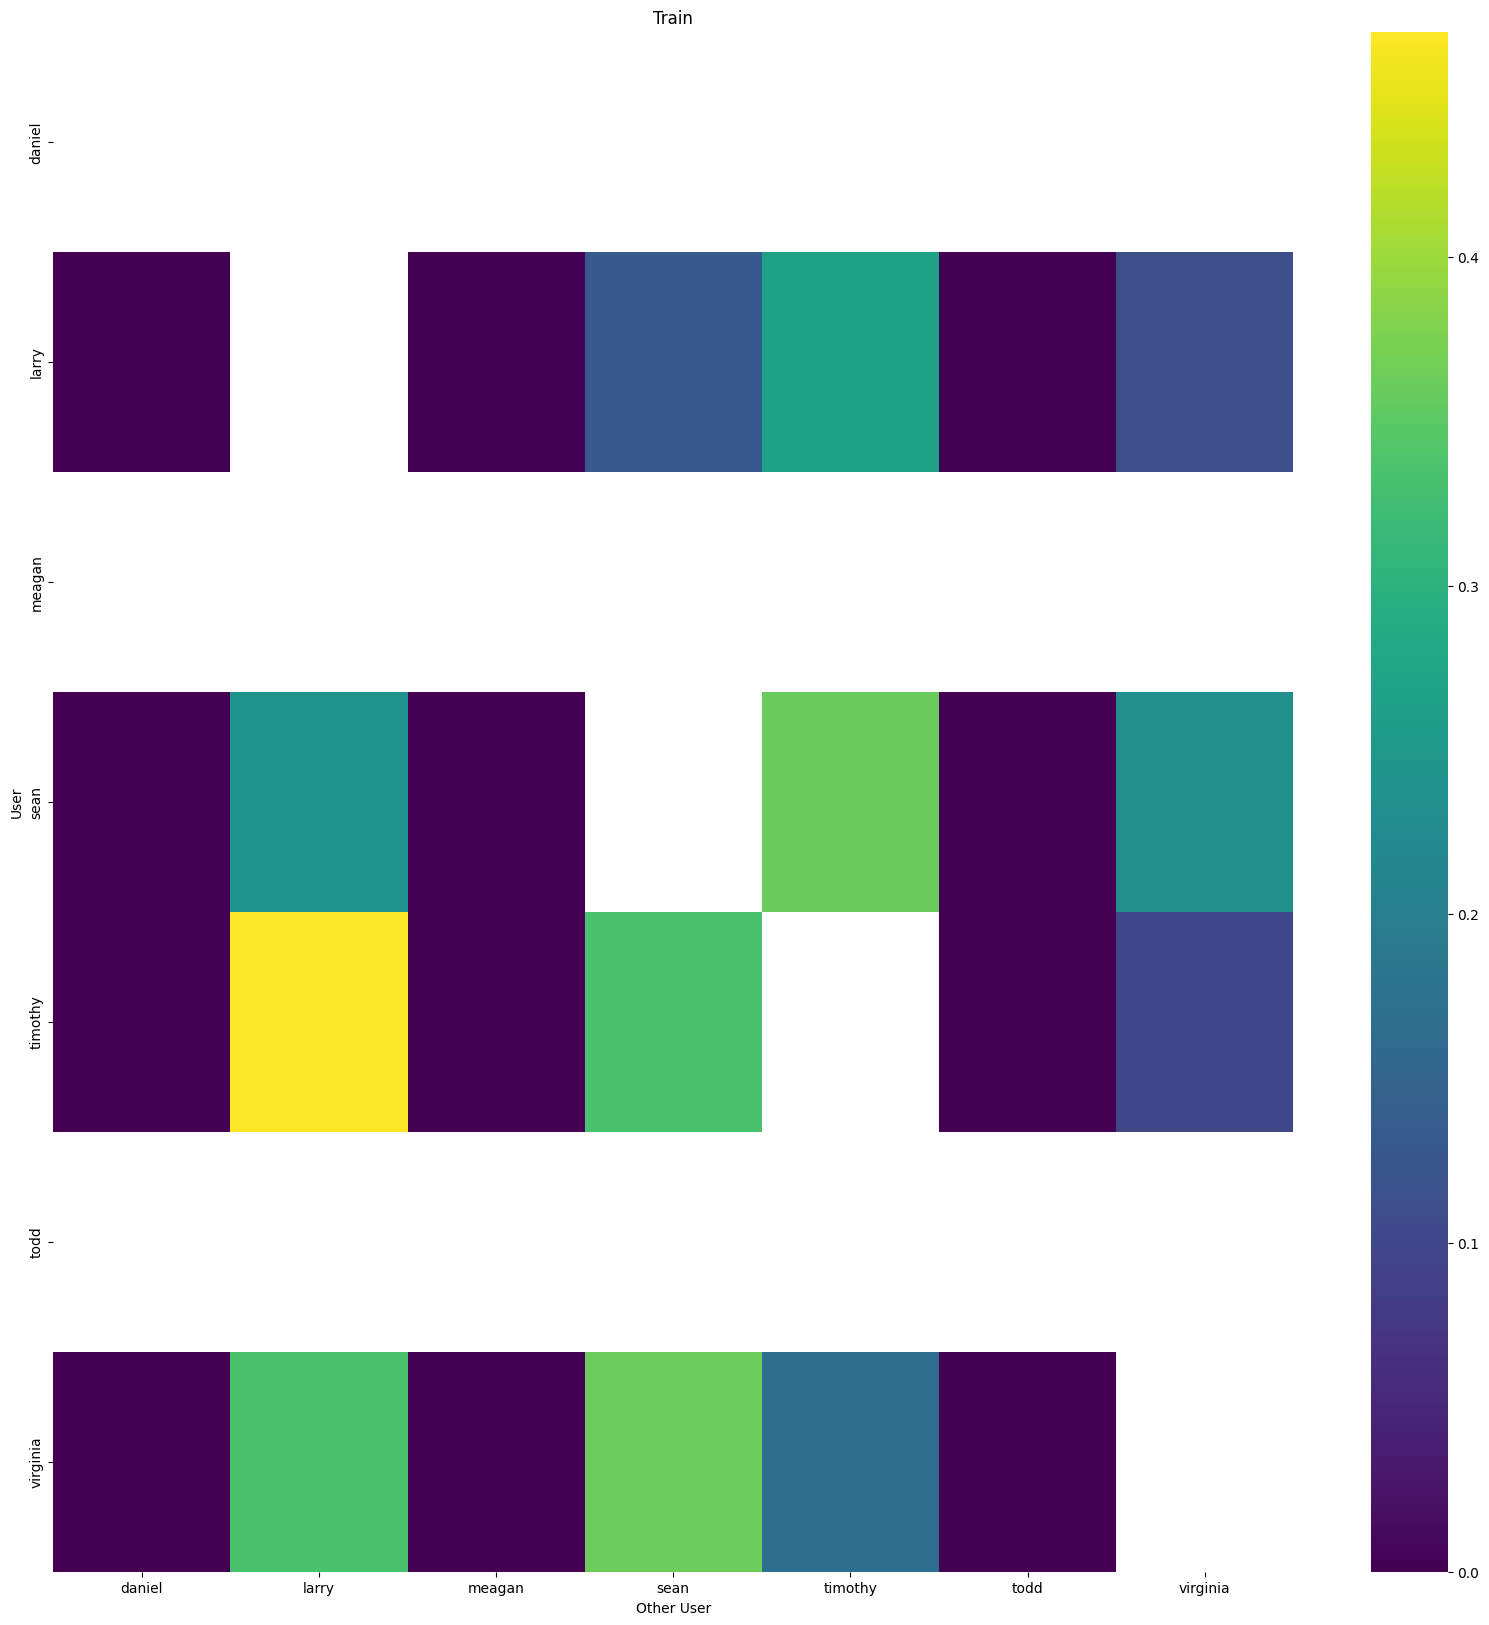

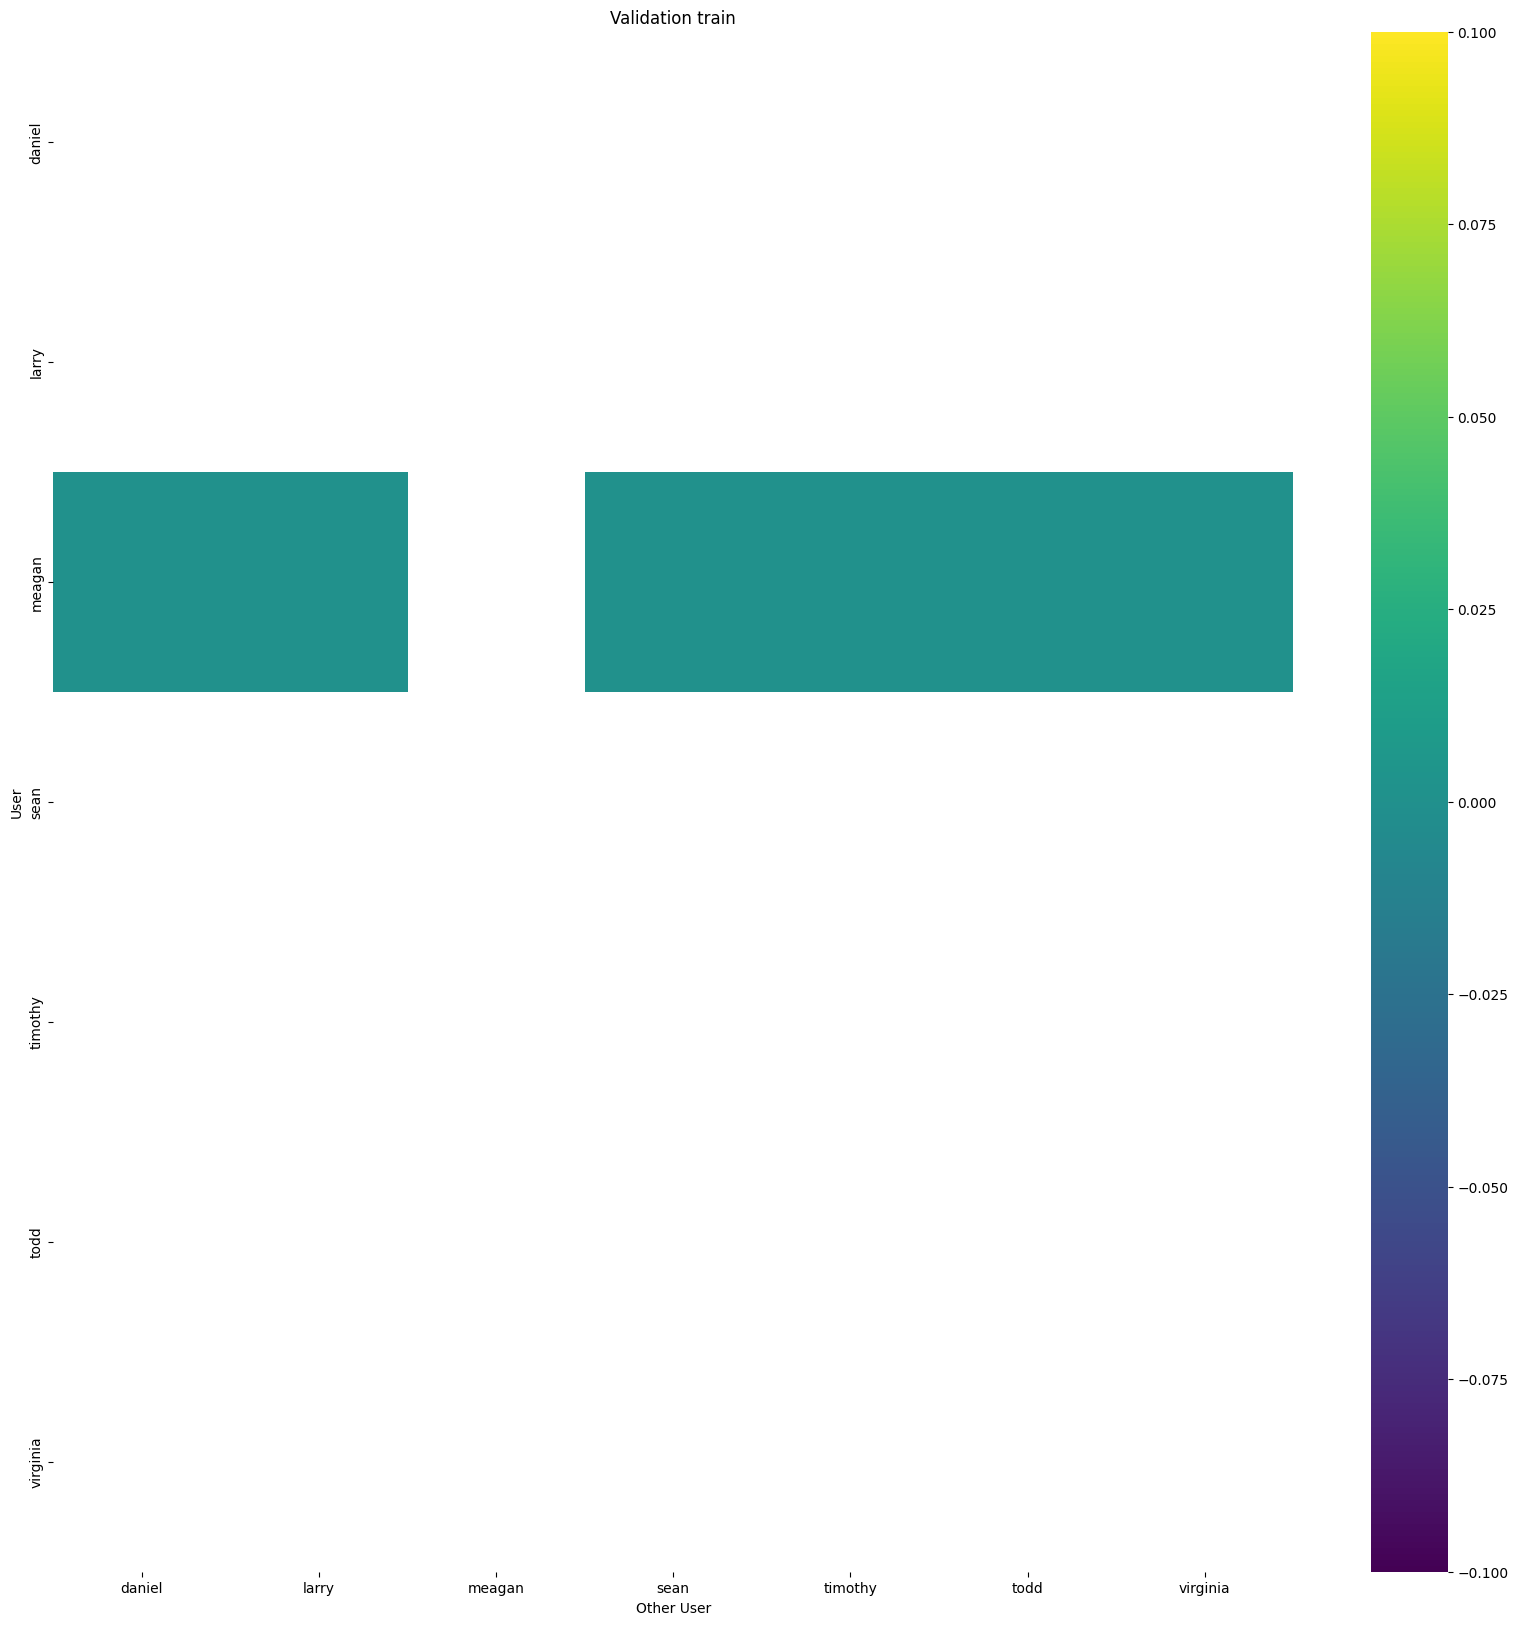

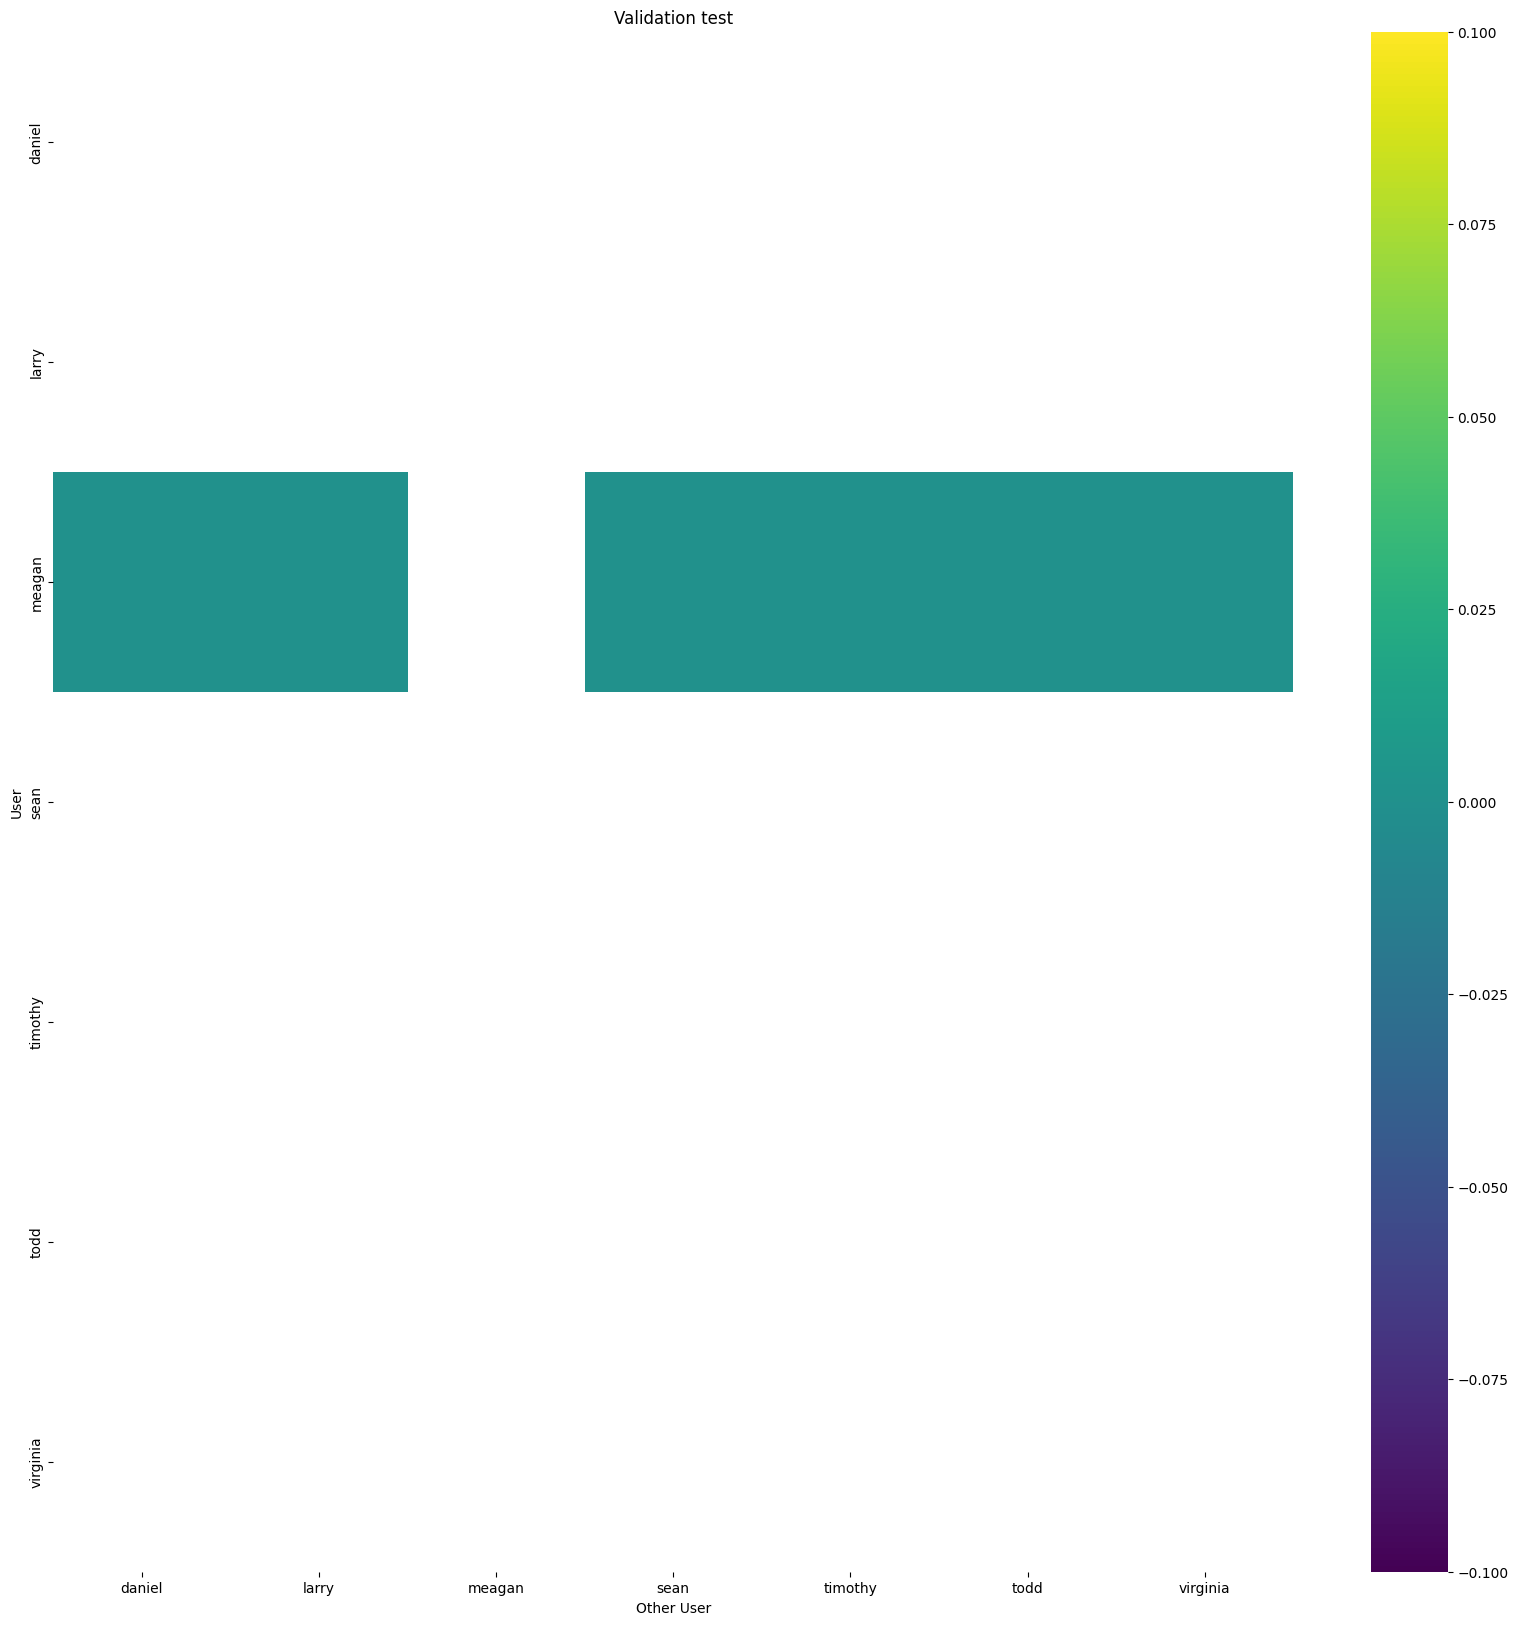

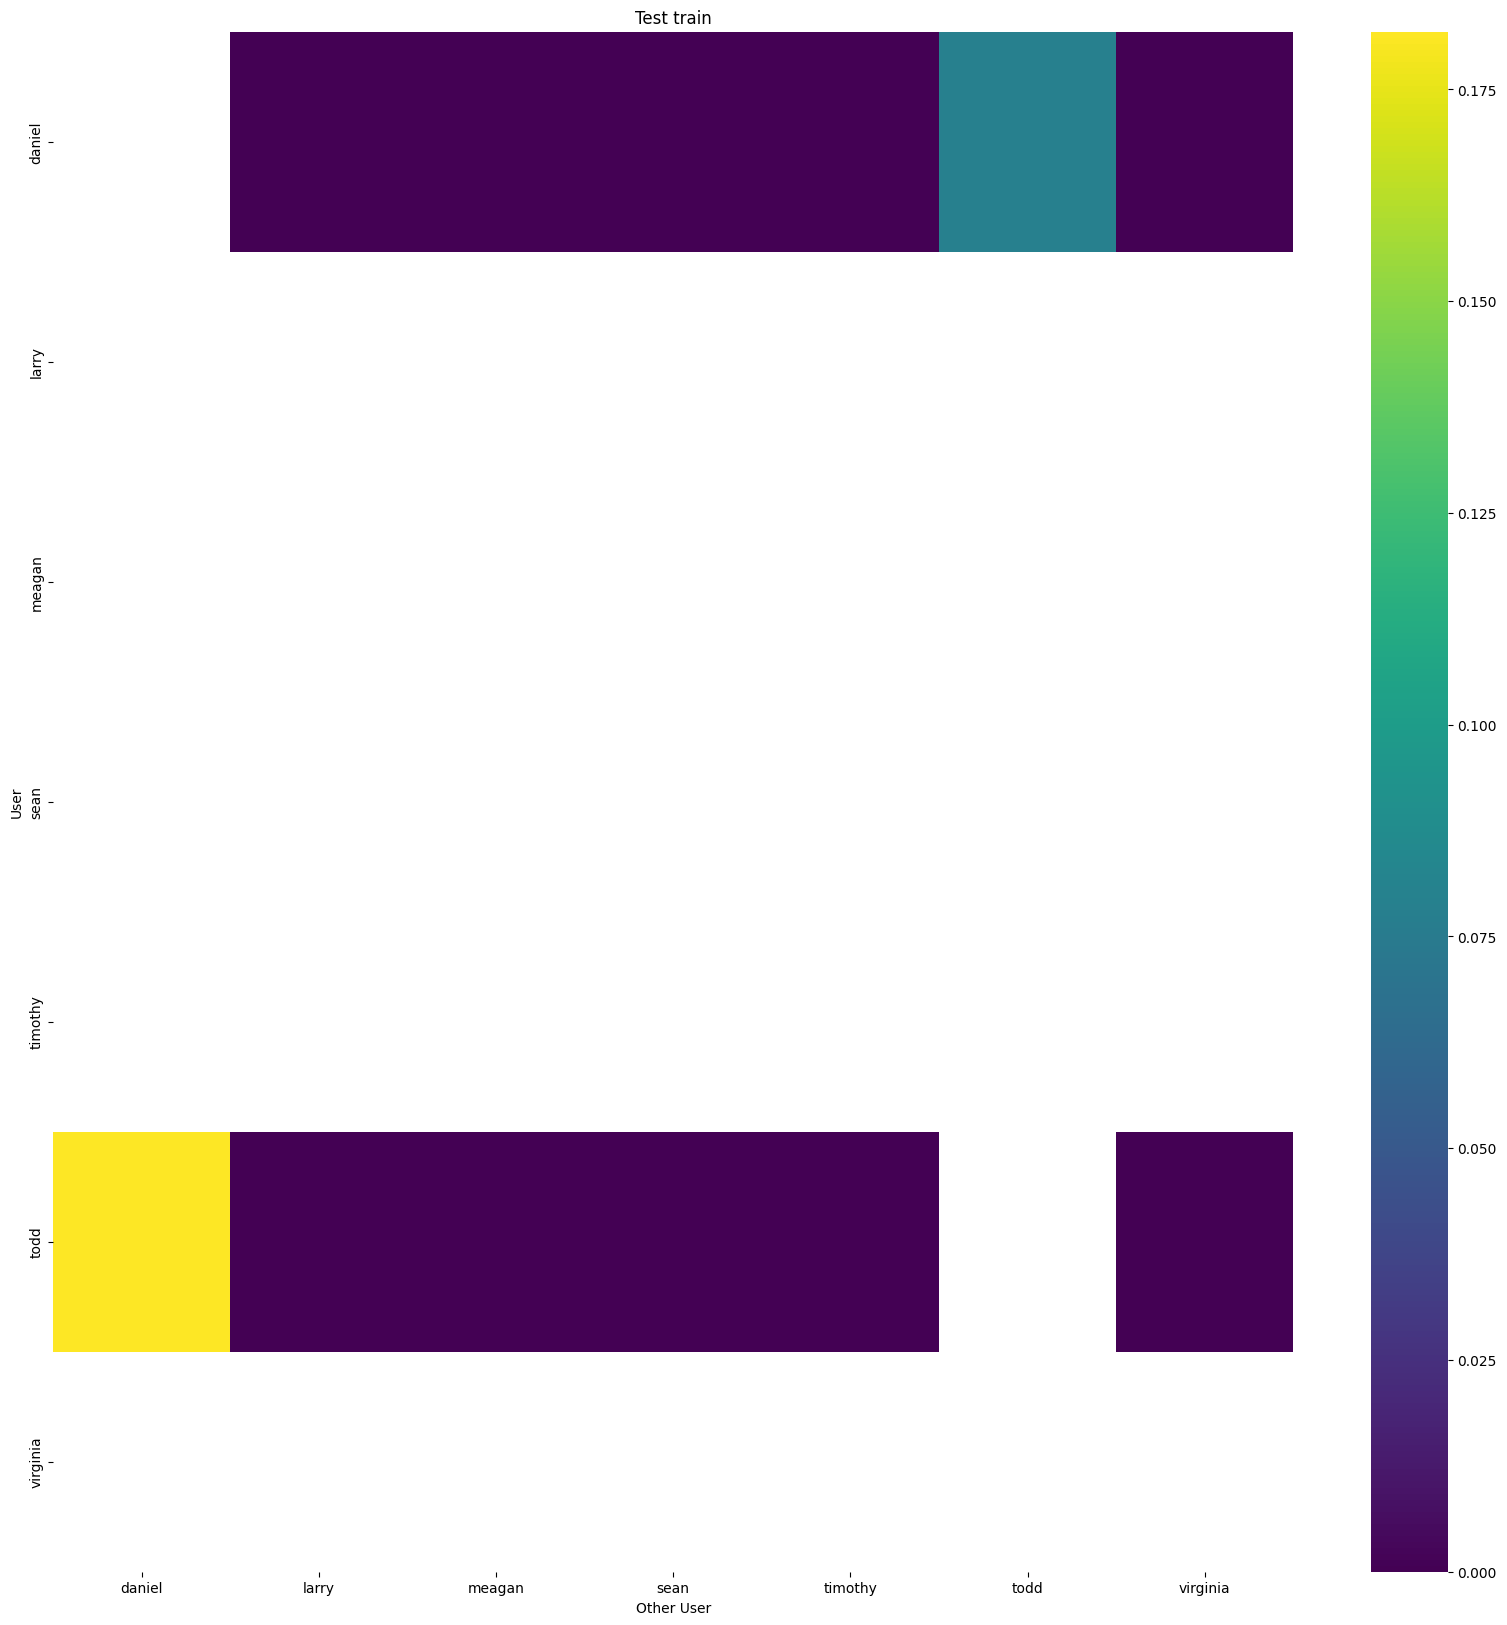

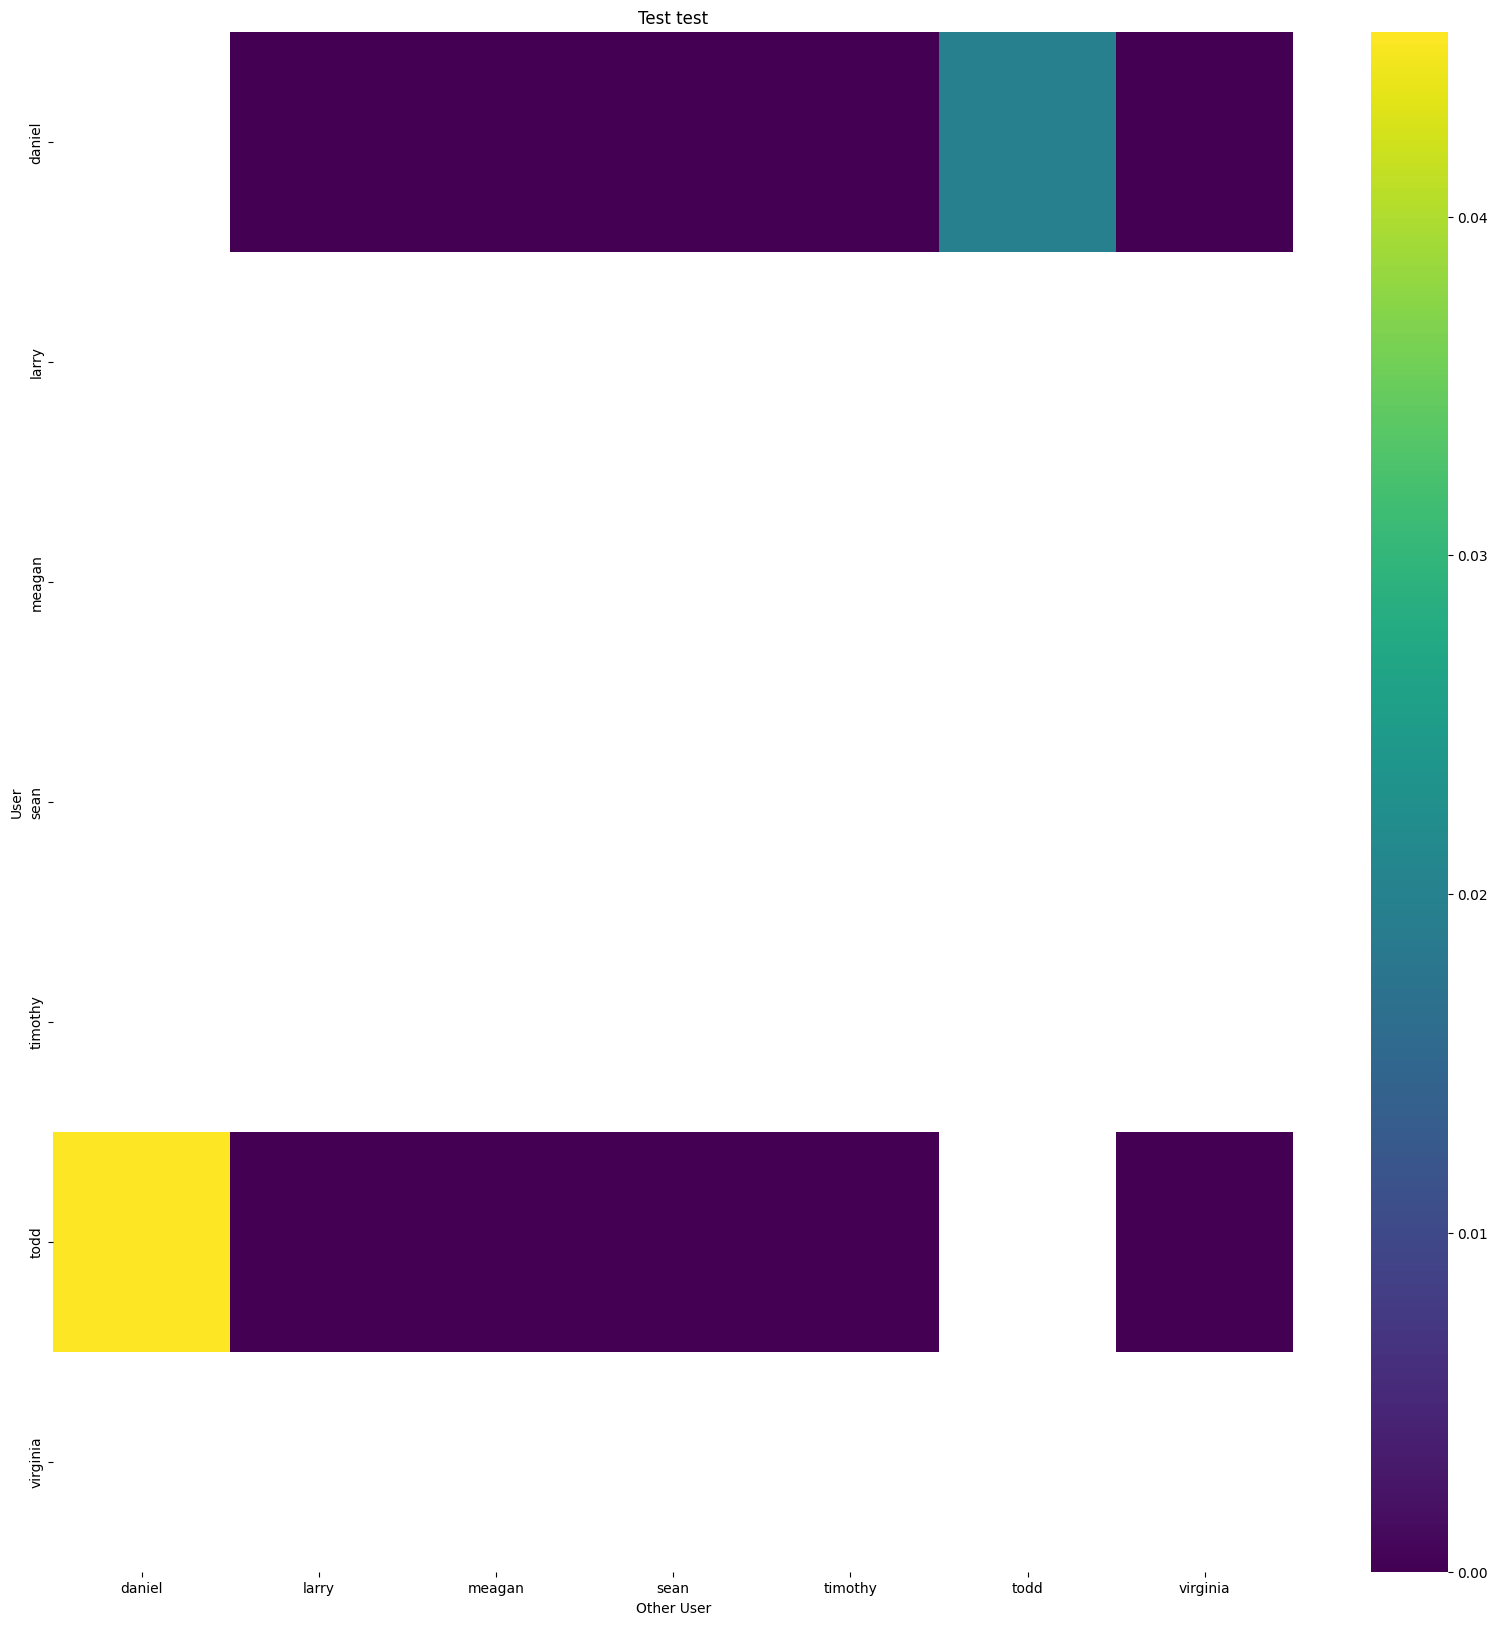

Alpha: 5.43718147277832
Min max affinity: 0.0 5.43718147277832
Min max affinity: 0.0 5.328437805175781
Min max affinity: 0.0 4.784719467163086
Min max affinity: 0.0 4.241001605987549
Min max affinity: 0.0 5.43718147277832
Min max affinity: 0.0 4.784719467163086
Max affinity: 5.43718147277832


In [12]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

scaler = StandardScaler()
scaler.fit(train_df[spoti.NUMERICAL_FEATURES])
df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES] = scaler.transform(df_matrix_mf_filtered[spoti.NUMERICAL_FEATURES])
train_df[spoti.NUMERICAL_FEATURES] = scaler.transform(train_df[spoti.NUMERICAL_FEATURES])
val_df_train[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_train[spoti.NUMERICAL_FEATURES])
val_df_test[spoti.NUMERICAL_FEATURES] = scaler.transform(val_df_test[spoti.NUMERICAL_FEATURES])
test_df_train[spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_train[spoti.NUMERICAL_FEATURES])
test_df_test[spoti.NUMERICAL_FEATURES] = scaler.transform(test_df_test[spoti.NUMERICAL_FEATURES])

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [13]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([7, 325])
Train dataset shape: torch.Size([7, 325])
Validation train dataset shape: torch.Size([7, 325])
Validation test dataset shape: torch.Size([7, 325])
Test train dataset shape: torch.Size([7, 325])
Test test dataset shape: torch.Size([7, 325])


In [14]:
whole_matrix_dataset.R

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [2.3924, 0.0000, 1.6312,  ..., 1.6312, 0.0000, 1.6312],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [2.7186, 2.7186, 3.6973,  ..., 1.6312, 5.0022, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 1.6312],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       device='mps:0')

# Define and train the MultiVAE model

In [15]:
num_latent_factors = 200
lmf = LogisticMatrixFactorization(
    num_users=whole_matrix_dataset.R.shape[0],
    num_items=whole_matrix_dataset.R.shape[1],
    num_factors=num_latent_factors,
    reg_param=0.01,
    device=device,
    dtype=dtype,
)
lmf.to(device)

num_epochs = 100
best_model = lmf.train_model(
    R=train_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R,
    num_epochs=num_epochs,
    learning_rate=0.1,
    log_interval=1,
    tqdm=False,
    validation_df_features=df_matrix_mf_filtered,
    validation_features_columns=spoti.NUMERICAL_FEATURES,
    similarity_max_item=100
)

Epoch: 1 	 Loss: 9242.5127 	 MPR: 0.3931 	 NDCG@100: 0.1729 	 Recall@20: 0.1000 	 Recall@50: 0.1795 	 Similarity: 0.0077
Epoch: 2 	 Loss: 5170.6152 	 MPR: 0.3410 	 NDCG@100: 0.1886 	 Recall@20: 0.1000 	 Recall@50: 0.1538 	 Similarity: 0.0094
Epoch: 3 	 Loss: 3308.6106 	 MPR: 0.2815 	 NDCG@100: 0.2053 	 Recall@20: 0.0500 	 Recall@50: 0.2051 	 Similarity: 0.0076
Epoch: 4 	 Loss: 2380.4192 	 MPR: 0.2471 	 NDCG@100: 0.2147 	 Recall@20: 0.2000 	 Recall@50: 0.2308 	 Similarity: 0.0168
Epoch: 5 	 Loss: 1986.7050 	 MPR: 0.2296 	 NDCG@100: 0.2103 	 Recall@20: 0.1000 	 Recall@50: 0.2051 	 Similarity: 0.0122
Epoch: 6 	 Loss: 1755.1688 	 MPR: 0.2155 	 NDCG@100: 0.2206 	 Recall@20: 0.2000 	 Recall@50: 0.2051 	 Similarity: 0.0104
Epoch: 7 	 Loss: 1668.6121 	 MPR: 0.2189 	 NDCG@100: 0.2166 	 Recall@20: 0.1500 	 Recall@50: 0.2051 	 Similarity: 0.0103
Epoch: 8 	 Loss: 1582.7057 	 MPR: 0.2114 	 NDCG@100: 0.2163 	 Recall@20: 0.1500 	 Recall@50: 0.2051 	 Similarity: 0.0121
Epoch: 9 	 Loss: 1539.6721 	 MPR

In [16]:
losses_df = pd.DataFrame(
    [
        lmf.losses.cpu().numpy(),
        lmf.validation_losses.cpu().numpy(),
        lmf.ndcg_history.cpu().numpy(),
        lmf.recall20_history.cpu().numpy(),
        lmf.recall50_history.cpu().numpy(),
        lmf.mpr_history.cpu().numpy(),
        lmf.similarity_history.cpu().numpy(),
    ]
).T
losses_df.columns = ["loss", "validation_loss", "ndcg", "r20", "r50", "mpr", "similarity"]

px.line(
    losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss"
).show()
px.line(losses_df, x=losses_df.index, y=["ndcg", "r20", "r50", "mpr", "similarity"], title="Metrics").show()

In [17]:
total_loss, ndcg, recall_20, recall_50, mpr, similarity = best_model.evaluate_model(
    R=whole_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R,
    features_columns=spoti.NUMERICAL_FEATURES,
    df_features=df_matrix_mf_filtered,
    similarity_max_item=100
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")
print(f"Similarity: {similarity}")

Total loss: 1870.003173828125
NDCG_100: 0.20908822119235992
Recall_20: 0.15000000596046448
Recall_50: 0.1794871836900711
MPR: 0.31163614988327026
Similarity: 0.023071283474564552


In [18]:
df_tracks = df_matrix_mf_filtered.copy()
df_tracks = df_tracks.sample(frac=1) # Shuffle the dataframe
df_tracks = df_tracks[:150] # Keep only 1000 tracks
df_tracks["username"] = df_tracks["username"].cat.remove_unused_categories()
df_tracks["id"] = df_tracks["id"].cat.remove_unused_categories()

# Add item latent factors to the dataframe
n_components = 3
items_latent_columns = [f"track_latent_{i}" for i in range(n_components)]
pca_items = PCA(n_components=n_components)
pca_items.fit(lmf.item_vectors.cpu().numpy())
for track_id in df_tracks["id"].unique():
    latent_factors = lmf.get_item_factors([whole_matrix_dataset.itemnames_to_ids([track_id])[0]]).tolist()
    df_tracks.loc[df_tracks["id"] == track_id, items_latent_columns] = pca_items.transform(latent_factors).flatten()

# Add user latent factors to the dataframe
users_latent_columns = [f"user_latent_{i}" for i in range(n_components)]
pca_user = PCA(n_components=n_components)
pca_user.fit(lmf.user_vectors.cpu().numpy())
for user_id in df_tracks["username"].unique():
    latent_factors = lmf.get_user_factors([whole_matrix_dataset.usernames_to_ids([user_id])[0]]).tolist()
    df_tracks.loc[df_tracks["username"] == user_id, users_latent_columns] = pca_user.transform(latent_factors).flatten()

plotting.plot_latent_space(
    df=df_tracks,
    color=df_tracks["username"],
    text=df_tracks["username"],
    latent_columns=items_latent_columns,
).show()

plotting.plot_latent_space(
    df=df_tracks,
    color=df_tracks["username"],
    text=df_tracks["username"],
    latent_columns=users_latent_columns,
).show()

/Users/owen/local/unibe/ml/spotify-recommender/.venv/lib/python3.10/site-packages/plotly/express/_core.py:2044: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



/Users/owen/local/unibe/ml/spotify-recommender/.venv/lib/python3.10/site-packages/plotly/express/_core.py:2044: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [22]:
user_id = whole_matrix_dataset.usernames_to_ids(["timothy"])[0]
print(user_id)

# Get the top 10 recommendations for the user
top_10_ids, top_10_ids_scores = lmf.recommend(R=whole_matrix_dataset.R, user_id=user_id, top_k=20, filter_user_items=False)

# Get the top 10 recommendations for the user
whole_matrix_dataset.item_ids_to_df(top_10_ids)[spoti.PRETTY_PRINT_FEATURES]

4


,username,artists_names,name,release_year,popularity,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity
686,daniel,Damso,Δ. Dieu ne ment jamais,0.589616,0.231160,0.654444,0.499976,0.979121,-0.538457,-0.672831,-0.327193,-0.942006,0.523289,-0.165960,-0.048684,-0.436590,0.589616,0.233463,0.231160
1961,larry,PNL,J'suis QLF,0.520059,-0.726521,0.513342,-1.087086,0.979121,-0.370487,-0.400220,-0.327126,-0.692550,-1.147336,-0.203285,-0.627453,0.436009,0.520059,0.233463,-0.726521
2487,larry,Kid Cudi,Mr. Rager,0.102721,0.456497,0.109277,0.448945,0.979121,-0.688055,0.586225,4.593803,-0.216251,0.385917,-0.679663,-0.322008,0.763297,0.102721,0.233463,0.456497
2858,larry,PNL,Le monde ou rien,0.450503,-0.163179,-0.038239,-0.882962,-1.021324,0.569970,2.050599,-0.327210,0.822560,-0.385141,-0.642080,-0.611392,0.283418,0.450503,0.233463,-0.163179
3023,larry,Damso,Humains - Bonus Track,0.659172,-0.670187,-0.288374,0.357090,-1.021324,-0.456222,-0.709153,-0.327079,-0.565349,1.555798,1.451969,-0.230994,0.002327,0.659172,0.233463,-0.670187
3160,larry,Drake,Summers Over Interlude,0.520059,0.456497,0.288861,-1.954612,-1.021324,-0.660935,0.647400,-0.313719,-0.509521,-1.116316,0.423533,-0.310173,-1.612866,0.520059,-3.718733,0.456497
3528,larry,Diam's,La boulette (Génération nan nan),-0.175505,-0.106845,1.853811,-0.275694,0.979121,1.733512,0.173295,-0.327214,-0.138517,0.731563,-0.790097,0.249435,-0.030718,-0.175505,0.233463,-0.106845
3555,larry,Magic System,Magic in the Air (feat. Ahmed Chawki),0.380947,0.174826,-0.211409,1.372605,0.979121,-0.511337,-0.553157,-0.327221,-0.732124,1.728621,0.277501,1.020939,-0.002226,0.380947,0.233463,0.174826
3675,larry,Avicii,Wake Me Up,0.311390,-3.599565,-0.782231,0.739822,0.979121,-0.468470,-0.886560,-0.320526,-0.067850,0.660662,0.131432,0.521068,0.171447,0.311390,0.233463,-3.599565
3804,larry,R3HAB,All Around The World (La La La),0.728729,0.456497,0.506928,1.127657,-1.021324,-0.637315,0.930334,0.032650,-0.463588,0.115604,0.163320,0.709013,-1.087954,0.728729,0.233463,0.456497
